# Computational Techniques for Differential Equations

**Master in Applied and Computational Mathematics — Academic Year 2026/2027**

## Lab 2 — Poisson equation: nine-point differences, Neumann boundaries and Gauss–Seidel

**Names:** 
Sergio de María Saiz,
Jose Antonio Peña Mulero
---

### Problem 

Consider the Poisson equation
$$
\Delta u=f,\qquad (x,y)\in(0,1)^2,
$$
with Dirichlet boundary conditions prescribe as $u=u_\star$ on all four sides, where the exact solution and source are
$$
u_\star(x,y)=e^x\cos(\pi y),\qquad
f(x,y)=(1-\pi^2)e^x\cos(\pi y).
$$


In [356]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def u_exact(x, y):
    return np.exp(x) * np.cos(np.pi * y)

def f_rhs(x, y):
    return (1 - np.pi**2) * u_exact(x, y)

def lap_f(x, y):
    return (1 - np.pi**2)**2 * u_exact(x, y)

def g_neumann(y):
    return  np.cos(np.pi * y) # ux(0,y)


---

#### Part A — Nine-point discretization 

Adapt your five-point solver to use
$$
\Delta_h^{(9)}U_{ij}=\frac{4(U_{i+1,j}+U_{i-1,j}+U_{i,j+1}+U_{i,j-1})
+U_{i+1,j+1}+U_{i+1,j-1}+U_{i-1,j+1}+U_{i-1,j-1}-20U_{ij}}{6h^2}.
$$
For 0 smooth function,
$$
\Delta_h^{(9)}u=\Delta u+\frac{h^2}{12}\Delta^2u+O(h^4).
$$
1. Use $\Delta u=f$ to explain why the right-hand side must be corrected to
$$
F_{ij}=f(x_i,y_j)+\frac{h^2}{12}\Delta f(x_i,y_j).
$$
2. Implement `poisson9_dirichlet(m)`, returning `X, Y, U`. 
3. Compute the maximum error and observed orders. What changes if you omit the correction? Test the uncorrected scheme on the same meshes.

**Assembly hint.** Multiply by $-6h^2$. An interior equation has diagonal coefficient $20$, axial coefficients $-4$, diagonal-neighbour coefficients $-1$, and right-hand side $-6h^2F_{ij}$. Move known boundary values to the right-hand side.

**Convergence hint.** If you choose $m=8,16,32,64$, use
$$
p=\frac{\log(E_{h_1}/E_{h_2})}{\log(h_1/h_2)},\qquad h_k=\frac{1}{m_k+1},
$$
because doubling $m$ does not exactly halve $h$.



In [357]:
import numpy as np
from scipy import sparse # Use sparse matrix for A to be able to use greater values of m
import matplotlib.pyplot as plt


In [358]:
def set_matrix_coeffs(m:int, h:float):
    """Create matrix A of coefficients using 2 for loops

    Args:
        m_x (int): number interior points for x
        hx (float): stepsize in x axis
        m_y (int): number interior points for x
        hy (float): stepsize in y axis
        points_stencil (str, optional): number of points in the stencil: "5" or "9". Defaults to "5".
        
    Raises
        ValueError : if points_stencil not is "5" or "9"
        
    Returns
        A : matrix of coefficients
    """
    
    #   We will use the index k = (m_x)*j + i for i = 0,...,m_x-1, j = 0,...,m_y-1
    #   So the range of k is k = 0,..., m_x*m_y
    A = np.zeros((m**2, m**2)) # first index is value of k where the eqn is centered, second index are the elements


    for j in range(m): # 0,...,m_y-1: is in our notation 1,...,m_y
        for i in range(m): # 0,...,m_x-1: is in our notation 1,...,m_x
            
            
            # index of u in the vector of length m**2 (BCs = 0)
            k = m*j + i # k(i,j)
            
            # Set entries of A:
            

            # Coefficients that will repeat because of symmetry
            mid_coeff = -20/(6*h**2)
            vertical_coeff = 4/(6*h**2)
            horizontal_coeff = 4/(6*h**2)
            vertex_coeff = 1/(6*h**2) 
            
            # (i,j)
            A[k,k] = mid_coeff
            
            # (i-1, j) if not in boundary
            if i>0:  # k(i-1, j) = m_x*j +i-1 = k(i,j) -1
                A[k, k-1] = horizontal_coeff
                
                
            # (i+1, j) if not in boundary
            if i<m-1: # k(i+1, j) = m_x*j +i+1 = k(i,j) +1
                A[k, k+1] = horizontal_coeff
        
        
            
            if j>0: # (i, j-1) if not in boundary
                A[k, k-m] = vertical_coeff # k(i, j-1) = m_x*(j-1) +i = k(i,j) -m_x
                if i>0:
                    A[k, k-m-1] = vertex_coeff
                if i<m-1:
                    A[k, k-m+1] = vertex_coeff
                
                
            # (i, j+1) if not in boundary
            if j<m-1: # k(i, j+1) = m_x*(j+1) +i = k(i,j) +m_x
                A[k, k+m] = vertical_coeff
                if i>0:
                    A[k, k+m-1] = vertex_coeff
                if i<m-1:
                    A[k, k+m+1] = vertex_coeff
            
            
    return A

In [359]:
def poisson9_dirichlet(m, corrected=True):

    # -----------------------------------------------------------------------------------------------------------
    # Step 1: Discretize domain [0, 1] × [0, 1]
    
    # In this case X and Y are the same, but not in general
    X = np.linspace(start=0, stop=1, num=m+2) # In total m_x+2 points
    Y = np.linspace(start=0, stop=1, num=m+2) # In total m_y+2 points
    
    h = X[1]-X[0] # distance between 2 consecutive points
    
    
    # -----------------------------------------------------------------------------------------------------------
    # Step 2: Build sparse matrix A for the 5-point Laplacian
    
    #   We will use the index k = (m_x)*j + i for i = 0,...,m_x-1, j = 0,...,m_y-1
    #   So the range of k is k = 0,..., m_x*m_y
    A = set_matrix_coeffs(m, h)
    # Finally we use sparse to use an sparse array instead of a matrix
    A = sparse.csr_matrix(A)
        
    
            
        
    # -----------------------------------------------------------------------------------------------------------
    # Step 3: Assemble RHS vector
        # Apply correction explained in docstring using fxx = fyy = -base
    if corrected:
        f = lambda x,y: f_rhs(x,y) + (h**2 / 12)* lap_f(x,y)

    else:
        f = lambda x,y: f_rhs(x,y)
    
            
        # BCs
        
    g = {
        "a": lambda y: u_exact(0, y),
        "b": lambda y: u_exact(1, y),
        "c": lambda x: u_exact(x, 0),
        "d": lambda x: u_exact(x, 1)
    }
    
    rhs = np.zeros(m*m)
    
    for j in range(m):
        y = Y[j+1] # Y includes boundary points at 0 and m+1, so we take values at 1,...,m 
        
        for i in range(m):
            
            x = X[i+1] # X includes boundary points at 0 and m+1, so we take values at 1,...,m 
            
            k = m*j+i
                        
            rhs[k] = f(x, y) # Base rhs with no BCs
            
            # ADD BCs
            
            if i == 0: # In this case would it is centered with our notation in (1, j) so u_0j = g_a(j) appears
                rhs[k] -= (4/6)*g["a"](y)/h**2
                
                rhs[k] -= (1/6)*g["a"](y-h)/h**2

                rhs[k] -= (1/6)*g["a"](y+h)/h**2
                
                
            elif i == m-1: # In this case would it is centered with our notation in (m_x, j) so u_(mx+1) j = g_b(j) appears
                rhs[k] -= (4/6)*g["b"](y)/h**2
                
                rhs[k] -= (1/6)*g["b"](y-h)/h**2

                rhs[k] -= (1/6)*g["b"](y+h)/h**2
                
                
                
            if j == 0: # In this case would it is centered with our notation in (i, 1) so u_i0 = g_c(i) appears
                rhs[k] -= (4/6)*g["c"](x)/h**2
                rhs[k] -= (1/6)*g["c"](x-h)/h**2
                rhs[k] -= (1/6)*g["c"](x+h)/h**2
                
                # Compensate Verteces
                if i == 0: 
                    rhs[k] += (1/6)*g["c"](x-h)/h**2
                    
                if i == m-1:
                    rhs[k] += (1/6)*g["c"](x+h)/h**2
                            
            elif j == m-1: # In this case would it is centered with our notation in (i, m_x) so u_i (my+1) = g_d(j) appears
                rhs[k] -= (4/6)*g["d"](x)/h**2
                rhs[k] -= (1/6)*g["d"](x-h)/h**2
                rhs[k] -= (1/6)*g["d"](x+h)/h**2
                
                if i == 0: 
                    rhs[k] += (1/6)*g["d"](x-h)/h**2
                    
                if i == m-1:
                    rhs[k] += (1/6)*g["d"](x+h)/h**2
            
    
    # -----------------------------------------------------------------------------------------------------------
    
    # Step 4: Solve linear system AU = F
    # spsolve optimized to solve sparse matrices
    U_vector = sparse.linalg.spsolve(A, rhs) # Vector of length m_x*m_y (the index is k = m_x*j+i)
    
    
    # -----------------------------------------------------------------------------------------------------------
    # Step 5: Reconstruct solution including boundary values

    U = np.zeros((m+2, m+2)) # uij for i,j=0,..., m+1
    
    # BCs:
    U[:, 0] = g["c"](X)
    U[:, -1] = g["d"](X) # Column m_y+1
    
    # Overwrite vertex with conds on x (these have priority)
    U[0, :] = g["a"](Y)
    U[-1, :] = g["b"](Y) # row m_x+1
    
   
    # Inner points:
    for j in range(m):
        
        for i in range(m):
            
            k = m*j + i
            
            U[i+1, j+1] =  U_vector[k]# Only change values for i = 1,...,m_x; j= 1,...,m_y.
            
    
    return X, Y, U

# TODO: run the corrected and uncorrected convergence studies.

In [360]:

def dist_linf(u_approx, u_exact):
    return np.max(np.abs(u_approx - u_exact))

In [361]:

def apply_exact(X, Y, u):
    """Apply u to the grid

    Args:
        X, Y : 1D ndarrays
                Meshgrid of all grid points including boundaries.
        u (function): function to evaluate
        
    Returns
        U: 2D ndarrays
                Evaluation of U in the grid
    """
    
    # We may have different lengths
    n = len(X)
    m = len(Y)
    
    U = np.zeros((n, m))
    
    for i in range(n):
        x = X[i]
        for j in range(m):
            y = Y[j]
            U[i,j] = u(x, y)
            
    
    # Also can use np.meshgrid in the following way:
    #     XX, YY = np.meshgrid(X, Y, indexing="ij")
    #     U = u (XX, YY)
    
    return U

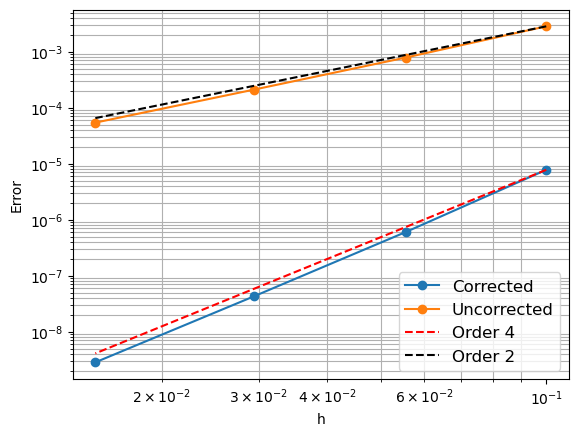

In [362]:
m_list = [8, 16, 32, 64]
h_list = np.array([1/(m+2) for m in m_list])

error_corrected = []
error_uncorrected = []

for m in m_list:

    # print(m)
    X, Y, U_cor = poisson9_dirichlet(m, corrected=True)
    # print(f"X = {X}")
    # print(f"Y = {Y}")
    
    # print(f"U = {U}")
    U_exact = apply_exact(X, Y, u_exact)
    
    # print(f"U_exact = {U_exact}")
    error_corrected.append(dist_linf(U_cor, U_exact))
   # print(f"U_corrected = {U}")



    X, Y, U_uncor = poisson9_dirichlet(m, corrected=False)
    # print(f"X = {X}")
    # print(f"Y = {Y}")
    
   # print(f"U_uncorrected = {U_uncor}")
    U_exact = apply_exact(X, Y, u_exact)
    
    #print(f"U_exact = {U_exact}")
    error_uncorrected.append(dist_linf(U_uncor, U_exact))


# print(f"error_l2_normalized = {error_l2_normalized}")
# print(h_list)
plt.loglog(h_list, error_corrected, "o-", label = "Corrected")
plt.loglog(h_list, error_uncorrected, "o-", label = "Uncorrected")

plt.loglog(h_list, (error_corrected[0]/h_list[0]**4)*h_list**4, "r--", label = "Order 4")
plt.loglog(h_list, (error_uncorrected[0]/h_list[0]**2)*h_list**2, "k--", label = "Order 2")

plt.legend(fontsize=12, loc="best")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="minor")

plt.show()

Exact:

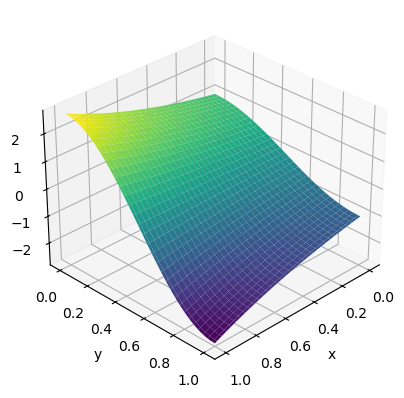

In [363]:
fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U_exact, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.xlabel("x")
plt.ylabel("y")

ax.view_init(elev = 30, azim = 45)
plt.show()

Corrected:

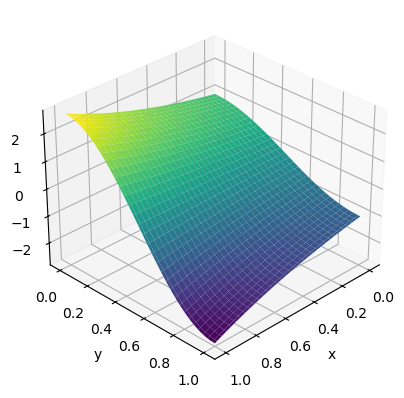

In [364]:
fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U_cor, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.xlabel("x")
plt.ylabel("y")

ax.view_init(elev = 30, azim = 45)
plt.show()

Uncorrected:

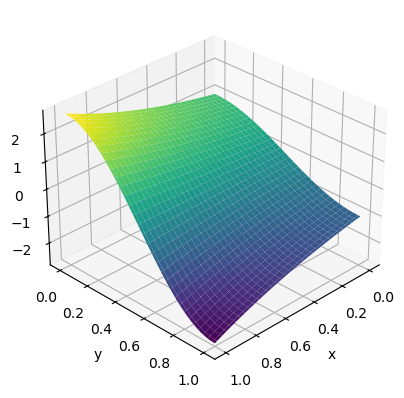

In [365]:
fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U_uncor, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.xlabel("x")
plt.ylabel("y")


ax.view_init(elev = 30, azim = 45)
plt.show()

---

### Part B — Fourth-order one-sided Neumann condition 

Now impose $u_x(0,y)=g(y)$ on the left side. The values $U_{0,j}$, $j=1,\ldots,m$, become unknowns. Keep the other three sides and the corners fixed by Dirichlet data.

Approximate the derivative using **only physical nodes**, with the fourth-order forward formula
$$
u_x(0,y_j)=\frac{-25u(0,y_j)+48u(h,y_j)-36u(2h,y_j)+16u(3h,y_j)-3u(4h,y_j)}{12h}+O(h^4).
$$
Thus impose the discrete boundary equation
$$
-25U_{0,j}+48U_{1,j}-36U_{2,j}+16U_{3,j}-3U_{4,j}=12h g_j.
$$

1. Implement `poisson9_mixed(m)`. 
2. Repeat the convergence study. Plot these errors together with those from Part A. Does the mixed method retain fourth order?
3. Explain why using a second-order one-sided derivative here would generally prevent fourth-order global convergence.


In [366]:
def poisson9_mixed(m):
    

    # -----------------------------------------------------------------------------------------------------------
    # Step 1: Discretize domain [a, b] × [c, d]
    
    # In this case X and Y are the same, but not in general
    X = np.linspace(start=0, stop=1, num=m+2) # In total m_x+2 points
    Y = np.linspace(start=0, stop=1, num=m+2) # In total m_y+2 points
    
    h = X[1]-X[0] # distance between 2 consecutive points
    
    
    # -----------------------------------------------------------------------------------------------------------
    # Step 2: Build sparse matrix A for the 5-point Laplacian
    
    #   We will use the index k = (m_x)*j + i for i = 0,...,m_x-1, j = 0,...,m_y-1
    #   So the range of k is k = 0,..., m_x*m_y

    #   We will use the index k = (m_x)*j + i for i = 0,...,m_x-1, j = 0,...,m_y-1
    #   U_{0,j} become unknowns, so consider m+1 instead of m
    A = np.zeros(((m+1)*m, (m+1)*m)) # first index is value of k where the eqn is centered, second index are the elements

    # A without Neumann
    for j in range(m): # 0,...,m-1
        for i in range(1, m+1): # 0,...,m-1
            
            
            # index of u in the vector of length m**2 (BCs = 0)
            k = (m+1)*j + i # k(i,j)
            
            # Set entries of A:
            

            # Coefficients that will repeat because of symmetry
            mid_coeff = -20/(6*h**2)
            vertical_coeff = 4/(6*h**2)
            horizontal_coeff = 4/(6*h**2)
            vertex_coeff = 1/(6*h**2) 
            
            # (i,j)
            A[k,k] = mid_coeff # center
            
            A[k, k-1] = horizontal_coeff # left
                
                
            # (i+1, j) if not in boundary
            if i<m: # k(i+1, j) = m_x*j +i+1 = k(i,j) +1
                A[k, k+1] = horizontal_coeff # Right
                
            
            if j>0: # (i, j-1) if not in boundary
                A[k, k-(m+1)] = vertical_coeff # Down
                A[k, k-(m+1)-1] = vertex_coeff # diagonal left down
                if i<m:
                    A[k, k-(m+1)+1] = vertex_coeff # Diagonal right down
                
                
            if j<m-1:
                A[k, k+(m+1)] = vertical_coeff # Up
                A[k, k+(m+1)-1] = vertex_coeff # diagonal left up
                if i<m:
                    A[k, k+(m+1)+1] = vertex_coeff # Diagonal right up
            
            
    # Add Neumann coeffs to A
    
    for j in range(m):
        k = (m+1)*j # k(0,j)
        
        A[k, k] = -25
        A[k, k+1] = 48
        A[k, k+2] = -36
        A[k, k+3] = 16
        A[k, k+4] = -3
        
        

    # Finally we use sparse to use an sparse array instead of a matrix
    A = sparse.csr_matrix(A)
        
    
    # -----------------------------------------------------------------------------------------------------------
    # Step 3: Assemble RHS vector
        # Apply correction explained in docstring using fxx = fyy = -base

    f = lambda x,y: f_rhs(x,y)
            
    # BCs
        
    g = {
        "a": lambda y: g_neumann(y),
        "b": lambda y: u_exact(1, y),
        "c": lambda x: u_exact(x, 0),
        "d": lambda x: u_exact(x, 1)
    }
    
    rhs = np.zeros((m+1)*m)
    
    for j in range(m):
        y = Y[j+1] # Y includes boundary points at 0 and m+1, so we take values at 1,...,m 
        
        for i in range(m+1):
            
            x = X[i] # X includes boundary points at 0 and m+1, so we take values at 1,...,m 
            
            k = (m+1)*j+i
            
            rhs[k] = f(x, y) # Base rhs with no BCs
            
            # ADD BCs
            
            # Cond Neumann sida a
            if i == 0:
                rhs[k] = 12*h*g["a"](y)
                continue
            
            # Dirichlet side b
            if i == m:
                rhs[k] -= (4/6)*g["b"](y)/h**2
                rhs[k] -= (1/6)*g["b"](y-h)/h**2
                rhs[k] -= (1/6)*g["b"](y+h)/h**2
                
                
                
            if j == 0: # In this case would it is centered with our notation in (i, 1) so u_i0 = g_c(i) appears
               # Dirichlet side c
                rhs[k] -= (4/6)*g["c"](x)/h**2
                rhs[k] -= (1/6)*g["c"](x-h)/h**2
                rhs[k] -= (1/6)*g["c"](x+h)/h**2
                
                # Compensate Verteces
                if i == m:
                    rhs[k] += (1/6)*g["c"](x+h)/h**2
                            
            elif j == m-1: # In this case would it is centered with our notation in (i, m_x) so u_i (my+1) = g_d(j) appears
                rhs[k] -= (4/6)*g["d"](x)/h**2
                rhs[k] -= (1/6)*g["d"](x-h)/h**2
                rhs[k] -= (1/6)*g["d"](x+h)/h**2
                    
                if i == m:
                    rhs[k] += (1/6)*g["d"](x+h)/h**2
    # -----------------------------------------------------------------------------------------------------------
    
    # Step 4: Solve linear system AU = F
    # spsolve optimized to solve sparse matrices
    U_vector = sparse.linalg.spsolve(A, rhs) # Vector of length m*m (the index is k = m*j+i)
    
    
    # -----------------------------------------------------------------------------------------------------------
    # Step 5: Reconstruct solution including boundary values

    U = np.zeros((m+2, m+2)) # uij for i,j=0,..., m+1
    
    # BCs:
    U[:, 0] = g["c"](X)
    U[:, -1] = g["d"](X) # Column m+1
    
    # Overwrite vertex with conds on x (these have priority)
    U[-1, :] = g["b"](Y) # row m+1
    
   
    # Inner points with side a:
    for j in range(m):
        
        for i in range(m+1):
            
            k = (m+1)*j + i
            
            U[i, j+1] =  U_vector[k]# Only change values for i = 1,...,m_x; j= 1,...,m_y.
            
    
    return X, Y, U

# TODO: verify the derivative coefficients; error/order table and comparison plot.

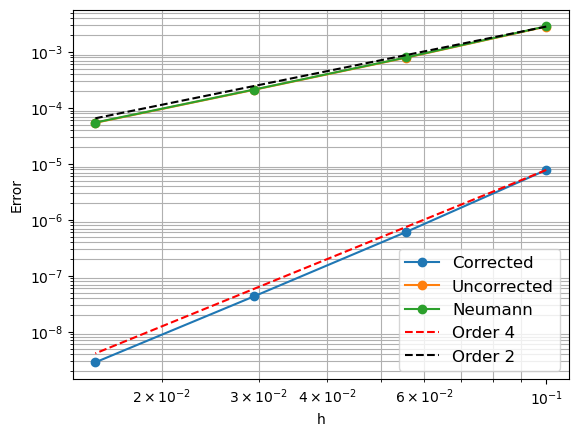

In [367]:
m_list = [8, 16, 32, 64]
h_list = np.array([1/(m+2) for m in m_list])

error_neu = []

for m in m_list:
    
    # Part B
    X, Y, U_neu = poisson9_mixed(m)
    
    
    U_exact = apply_exact(X, Y, u_exact)
    error_neu.append(dist_linf(U_neu, U_exact))


# print(f"error_l2_normalized = {error_l2_normalized}")
# print(h_list)
plt.loglog(h_list, error_corrected, "o-", label = "Corrected")
plt.loglog(h_list, error_uncorrected, "o-", label = "Uncorrected")
plt.loglog(h_list, error_neu, "o-", label = "Neumann")

plt.loglog(h_list, (error_corrected[0]/h_list[0]**4)*h_list**4, "r--", label = "Order 4")
plt.loglog(h_list, (error_uncorrected[0]/h_list[0]**2)*h_list**2, "k--", label = "Order 2")

plt.legend(fontsize=12, loc="best")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="minor")

plt.show()

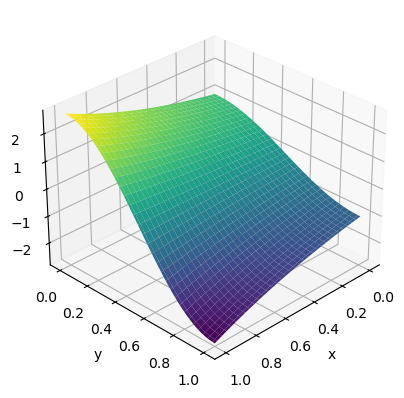

In [368]:
fig = plt.figure()
ax = plt.axes(projection = "3d")

X_grid, Y_grid = np.meshgrid(X, Y, indexing="ij")

ax.plot_surface(X_grid, Y_grid, U_neu, cmap = "viridis") # ax.plot3D plots lines between points, not the surface. 
# Use it for curves

plt.xlabel("x")
plt.ylabel("y")

ax.view_init(elev = 30, azim = 45)
plt.show()

A one-sided second order derivative would cause our method to be of second order because we are using the supremum norm without correcting f. Therefore, the error is the worst error committed, which will be order 2.

---

### Part C — Matrix-free Gauss–Seidel (3 marks)

Solve the **mixed problem from Part B** without assembling a matrix. Use the corrected source and the same fourth-order one-sided boundary equations.

For a strictly interior node, update
$$
U_{ij}\leftarrow\frac{4(U_{i+1,j}+U_{i-1,j}+U_{i,j+1}+U_{i,j-1})
+U_{i+1,j+1}+U_{i+1,j-1}+U_{i-1,j+1}+U_{i-1,j-1}-6h^2F_{ij}}{20}.
$$
For a left boundary node, update
$$
U_{0,j}\leftarrow\frac{48U_{1,j}-36U_{2,j}+16U_{3,j}-3U_{4,j}-12h g_j}{25}.
$$
Sweep in the order $i=0,\ldots,m$, $j=1,\ldots,m$, updating `U` **in place** with the latest available neighbour values. Keep Dirichlet nodes fixed. Initialize all unknowns to zero.

For the scaled system $AU=b$ defined in Parts A and B, stop when
$$
\frac{\|b-AU^{(k)}\|_\infty}{\max(1,\|b\|_\infty)}<10^{-12}.
$$
Compute the residual **from both the interior PDE rows and the one-sided Neumann rows**, without assembling $A$. Here $b$ includes the moved Dirichlet contributions. A small change between consecutive iterates alone is not a sufficient stopping test. Set a maximum iteration count and report a failure if it is reached.

1. Implement `gauss_seidel9_mixed(m, tol=1e-12, maxiter=50000)`.
2. For $m=15$, compare against the direct mixed solution and report the residual and iteration count.
3. If time permits, repeat with $m=31$. How does refinement affect iteration counts? Distinguish discretization error from algebraic error.

**Note:** The one-sided boundary row is not diagonally dominant. Therefore the familiar diagonal-dominance criterion does not establish convergence of Gauss–Seidel for this system; verify convergence in your numerical runs. General convergence analysis is outside the scope of this lab.

In [376]:
def gauss_seidel9_mixed(m, tol=1e-12, maxiter=50000):
      
    # Initialize 

    X = np.linspace(0, 1, m+2)
    Y = np.linspace(0, 1, m+2)
    h = X[1] - X[0]
    
    # f as matrix for inner points
    
    rhs = np.zeros((m+2, m+2))
    for i in range(1, m+1):
        # borders are 0 bc do not affect BCs
        rhs[i, 1:-1] = f_rhs(X[i+1], Y[1:-1])
        
        
    # BCs
        
    g = {
        "a": lambda y: g_neumann(y),
        "b": lambda y: u_exact(1, y),
        "c": lambda x: u_exact(x, 0),
        "d": lambda x: u_exact(x, 1)
    }
        
    # g as vector
    g_rhs = np.zeros(m+2)
    for j in range(1,m+1):
        g_rhs[j] = g["a"](Y[j])
        
    
    # Calculate b:
    b = np.zeros((m+2, m+2)) # Right hand side
    for j in range(1, m+1):
        b[0, j] = 12*h*g_rhs[j]
        
        for i in range(1, m+1):
            b[i, j] = 6*h**2*rhs[i,j]
    
    b_sup = np.max(np.abs(b))
        
    U = np.zeros((m+2,m+2))
    
    # BCs:
    U[:, 0] = g["c"](X)
    U[:, -1] = g["d"](X) # Column m+1
    
    # Overwrite vertex with conds on x
    U[-1, :] = g["b"](Y) # row m+1

        
    for iteration in range(maxiter): # Stopping criteria
        res = np.zeros((m+2, m+2)) # Boundary a are unknowns bc of Neumann
        for j in range(1, m+1):
            # Update U0j
            U[0, j] = (48*U[1, j]-36*U[2, j]+16*U[3, j]-3*U[4, j] - b[0, j])/25 
            
            
            for i in range(1, m+1): # 1 to m, does not change extremes of u (boundary values)
                sum_orthogonals = U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1]
                sum_diagonals =  U[i+1, j+1] + U[i+1, j-1] + U[i-1, j+1] + U[i-1, j-1]
                
                U[i, j] = (4*sum_orthogonals + sum_diagonals - b[i, j])/20
        
        
        # Calculate residuals when U has been updated
        for j in range(1, m+1):
            res[0,j] = 12*h*g_rhs[j] - (25*U[0, j] + 48*U[1, j]-36*U[2, j]+16*U[3, j]-3*U[4, j])
            
            for i in range(1, m+1): # 1 to m, does not change extremes of u (boundary values)
                sum_orthogonals = U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1]
                sum_diagonals =  U[i+1, j+1] + U[i+1, j-1] + U[i-1, j+1] + U[i-1, j-1]
                
                res[i, j]
                
            
        res_sup = np.max(np.abs(res))
        
        criteria = res_sup
        if b_sup> 1:
            criteria = res_sup/b_sup
        
        if  criteria < tol:
            return X, Y, U, res_sup, iteration
    
    # raise ValueError("Max Iterations Reached")
    print("Max Iterations Reached")
    return X, Y, U, res_sup, iteration
    

# TODO: direct/iterative comparison.

In [379]:
m = 15

X, Y, U_gs, relative_residual, iterations = gauss_seidel9_mixed(m)

X, Y, U_direct = poisson9_mixed(m)

difference = dist_linf(U_gs, U_direct)

print(f"m = {m}")
print(f"Iterations = {iterations}")
print(f"Relative residual = {relative_residual}")
print(f"Difference with direct solution = {difference}")

Max Iterations Reached
m = 15
Iterations = 49999
Relative residual = 49.41023582895038
Difference with direct solution = 0.01998649372645711


In [381]:
m = 31

X, Y, U_gs, relative_residual, iterations = gauss_seidel9_mixed(m)

X, Y, U_direct = poisson9_mixed(m)

difference = dist_linf(U_gs, U_direct)

print(f"m = {m}")
print(f"Iterations = {iterations}")
print(f"Relative residual = {relative_residual}")
print(f"Difference with direct solution = {difference}")

Max Iterations Reached
m = 31
Iterations = 49999
Relative residual = 49.85579783846403
Difference with direct solution = 0.009979300239459477
